<a href="https://colab.research.google.com/github/Chitra9xh/DL-LAB/blob/main/DL_LAB_4_Cont_10_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Boiler Plate

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

#Loading Data

In [4]:
data = load_breast_cancer()
X = data.data
y = data.target
print("Samples: ", X.shape[0])
print("Features: ", X.shape[1])

Samples:  569
Features:  30


#Train Test Split

In [7]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y #Stratify ensures the distribution of data in both training and testing data stays the same
)

#Standardization

In [26]:


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Convert to PyTorch Tensor

In [32]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

/tmp/ipykernel_1340/2947476391.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_1340/2947476391.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
/tmp/ipykernel_1340/2947476391.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_1340/2947476391.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or 

#Create DataLoaders

In [33]:
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#Define DNN

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.modules.activation import LeakyReLU

class DNN(nn.Module):
    def __init__(self, activation_name):
        super().__init__()
        # Select activation function
        if activation_name == "sigmoid":
            activation = nn.Sigmoid()
        elif activation_name == "tanh":
            activation = nn.Tanh()
        elif activation_name == "relu":
            activation = nn.ReLU()
        elif activation_name == "leaky_relu":
            activation = nn.LeakyReLU(negative_slope=0.01)
        else:
            raise ValueError("Invalid activation function")

        self.network = nn.Sequential(
            nn.Linear(30, 64),
            activation,
            nn.Linear(64, 32),
            activation,
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

# Training Function (Moved completely outside the DNN class)
def train_model(activation_name):
    model = DNN(activation_name)

    # Loss Function
    criterion = nn.CrossEntropyLoss()

    # Same Optimizer for all experiments
    # FIX: Changed `model = parameters(),` to `model.parameters(),`
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    epochs = 50
    train_losses = []
    validation_accuracies = []

    # Training loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        # Note: train_loader must be defined elsewhere in your notebook
        for X_batch, y_batch in train_loader:
            # Forward Pass
            outputs = model(X_batch)

            # Calculate Loss
            loss = criterion(outputs, y_batch)

            # Remove previous gradients
            optimizer.zero_grad()

            # Backpropagation
            loss.backward()

            # Update Parameters
            optimizer.step()

            running_loss += loss.item()

        # Average Training Loss
        epoch_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad(): # Prevents PyTorch from calculating gradients
            # Note: test_loader must be defined elsewhere in your notebook
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)

                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        accuracy = (100 * correct / total)
        train_losses.append(epoch_loss)
        validation_accuracies.append(accuracy)

    return train_losses, validation_accuracies

# Run Experiments
activations = ["sigmoid", "tanh", "relu", "leaky_relu"]
results = {}

for activation in activations:
    print(f"\nTraining with {activation.upper()}")
    losses, accuracies = train_model(activation)

    results[activation] = {
        "loss": losses,
        "accuracy": accuracies
    }


Training with SIGMOID

Training with TANH

Training with RELU

Training with LEAKY_RELU


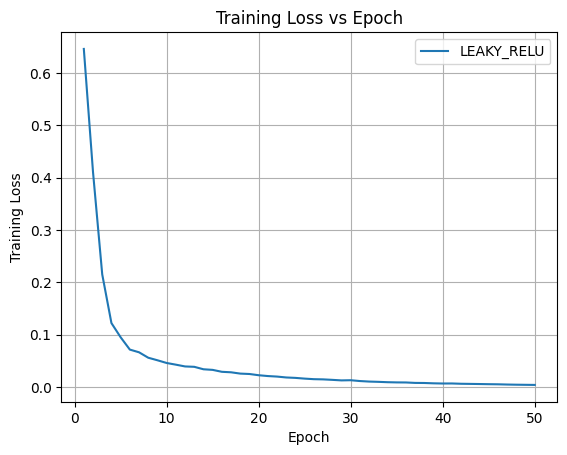

In [63]:
plt.plot(range(1,51), results [activation]["loss"], label = activation.upper())

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Training Loss vs Epoch")

plt.legend()
plt.grid()
plt.show()

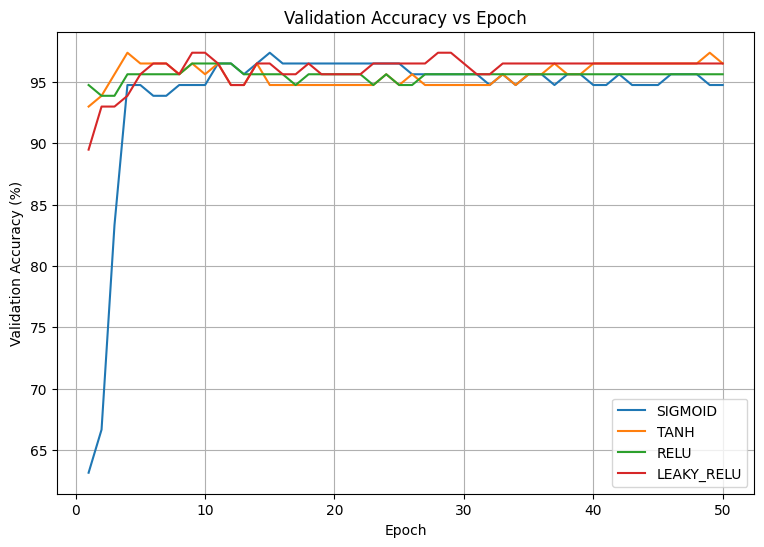


 Final Results
------------------------------------------------------------
SIGMOID     Loss = 0.0441 Accuracy = 94.74
TANH        Loss = 0.0197 Accuracy = 96.49
RELU        Loss = 0.0029 Accuracy = 95.61
LEAKY_RELU  Loss = 0.0038 Accuracy = 96.49


In [70]:
#Plot Validation Accuracy
plt.figure(figsize = (9,6))
for activation in activations:
    plt.plot(
        range(1,51),
        results[activation]["accuracy"], # Corrected 'Accuracy' to 'accuracy'
        label = activation.upper() # Corrected typo 'upeer()' to 'upper()'

    )
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title(
    "Validation Accuracy vs Epoch"
)

plt.legend()
plt.grid()
plt.show()

#Final Comparision

print("\n Final Results")

print ("-" * 60)

for activation in activations:
    final_loss = results[activation]["loss"][-1]
    final_accuracy = results[activation]["accuracy"][-1]
    print(
        f"{activation.upper():12s}"
        f"Loss = {final_loss:.4f} "
        f"Accuracy = {final_accuracy:.2f}"
    )